In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np
import pandas as pd
from src.features import cycle
from src._xgboost import search_params
from skforecast.recursive import ForecasterRecursive
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def plot_forecast(y_true, y_pred, title="Прогноз vs Истинные значения"):
    """
    Строит график сравнения истинных значений и прогноза
    """
    plt.figure(figsize=(12, 5))
    
    plt.plot(y_true.index, y_true.values, label='Истинные', color='blue', linewidth=1.5)
    plt.plot(y_pred.index, y_pred.values, label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    
    plt.xlabel('Дата')
    plt.ylabel('Значение')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [4]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

Глубина 0

In [57]:
depth = 0
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [7]:
study = search_params(df_train, df_val, exog_cols, target_col)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 18:48:55,666] A new study created in memory with name: no-name-4ccb148b-3f47-40b0-ad3b-1ab05a2b79e5
[I 2026-05-10 18:48:56,113] Trial 0 finished with value: 4.258779604055708 and parameters: {'lags': 2, 'n_estimators': 831, 'learning_rate': 0.4113124644472636, 'max_depth': 9, 'subsample': 0.6634533345930358, 'colsample_bytree': 0.6023796243171882, 'colsample_bylevel': 0.8419430161638837, 'colsample_bynode': 0.5014122360941766, 'reg_alpha': 1.466542174058174e-05, 'reg_lambda': 0.02090244605263472, 'gamma': 6.0716895242775595e-05, 'min_child_weight': 2, 'max_delta_step': 5}. Best is trial 0 with value: 4.258779604055708.
[I 2026-05-10 18:48:56,290] Trial 1 finished with value: 3.473984765555343 and parameters: {'lags': 5, 'n_estimators': 439, 'learning_rate': 0.520591643651176, 'max_depth': 8, 'subsample': 0.9160781509223803, 'colsample_bytree': 0.5532387410094126, 'colsample_bylevel': 0.9108159054607209, 'colsample_bynode': 0.8297268788126576, 'reg_alpha': 7.22202534528257

Лучшие параметры = {'lags': 3, 'n_estimators': 780, 'learning_rate': 0.040157510567018016, 'max_depth': 1, 'subsample': 0.4710928933867212, 'colsample_bytree': 0.6371364023788894, 'colsample_bylevel': 0.9736941090989871, 'colsample_bynode': 0.946972543763487, 'reg_alpha': 0.01944790370468654, 'reg_lambda': 0.0006979545452714358, 'gamma': 0.14535399079587752, 'min_child_weight': 14, 'max_delta_step': 13}
Лучший RMSE score = 2.8639123017670802


Глубина 5

In [38]:
depth = 5
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [39]:
study = search_params(df_train, df_val, exog_cols, target_col)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 18:54:25,710] A new study created in memory with name: no-name-5f859495-8635-459e-8655-ff1e00c16020
[I 2026-05-10 18:54:25,982] Trial 0 finished with value: 1.830388404010139 and parameters: {'lags': 5, 'n_estimators': 747, 'learning_rate': 0.034098614681019664, 'max_depth': 1, 'subsample': 0.8780961834316725, 'colsample_bytree': 0.9449212007395508, 'colsample_bylevel': 0.8664209033870734, 'colsample_bynode': 0.856930212163949, 'reg_alpha': 0.2385098570640351, 'reg_lambda': 0.013277395109753728, 'gamma': 0.008476349170888981, 'min_child_weight': 9, 'max_delta_step': 2}. Best is trial 0 with value: 1.830388404010139.
[I 2026-05-10 18:54:26,296] Trial 1 finished with value: 1.1631010952928342 and parameters: {'lags': 2, 'n_estimators': 759, 'learning_rate': 0.0015138357045397437, 'max_depth': 5, 'subsample': 0.4023422916441928, 'colsample_bytree': 0.42245105141345984, 'colsample_bylevel': 0.5428608742923747, 'colsample_bynode': 0.9589624234206898, 'reg_alpha': 1.87420399318

Лучшие параметры = {'lags': 1, 'n_estimators': 690, 'learning_rate': 0.00483818468394609, 'max_depth': 7, 'subsample': 0.667782205637987, 'colsample_bytree': 0.7636356097452922, 'colsample_bylevel': 0.48966780446123503, 'colsample_bynode': 0.6520755067104729, 'reg_alpha': 0.3878036627582577, 'reg_lambda': 0.0016536178007959621, 'gamma': 0.01760294328748257, 'min_child_weight': 2, 'max_delta_step': 1}
Лучший RMSE score = 0.6476949159153056


Глубина 10

In [53]:
depth = 10
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [54]:
study = search_params(df_train, df_val, exog_cols, target_col)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-10 18:57:28,944] A new study created in memory with name: no-name-73b9fcb5-d50b-4a27-93b5-e3ab19bacee9
[I 2026-05-10 18:57:29,172] Trial 0 finished with value: 0.46346396893430863 and parameters: {'lags': 1, 'n_estimators': 786, 'learning_rate': 0.003612681686566557, 'max_depth': 6, 'subsample': 0.7203017733087267, 'colsample_bytree': 0.8642531698315136, 'colsample_bylevel': 0.9393325775277592, 'colsample_bynode': 0.4573454225531157, 'reg_alpha': 0.002607572785034868, 'reg_lambda': 1.0070886616892844e-05, 'gamma': 4.157179634029126, 'min_child_weight': 4, 'max_delta_step': 6}. Best is trial 0 with value: 0.46346396893430863.
[I 2026-05-10 18:57:29,288] Trial 1 finished with value: 0.3855687999302272 and parameters: {'lags': 4, 'n_estimators': 358, 'learning_rate': 0.06908618988843575, 'max_depth': 7, 'subsample': 0.403484745538163, 'colsample_bytree': 0.6130672439612724, 'colsample_bylevel': 0.8535515141352729, 'colsample_bynode': 0.6667774897288252, 'reg_alpha': 0.046453881

Лучшие параметры = {'lags': 4, 'n_estimators': 358, 'learning_rate': 0.06908618988843575, 'max_depth': 7, 'subsample': 0.403484745538163, 'colsample_bytree': 0.6130672439612724, 'colsample_bylevel': 0.8535515141352729, 'colsample_bynode': 0.6667774897288252, 'reg_alpha': 0.04645388127570657, 'reg_lambda': 0.17273613633249837, 'gamma': 0.06877642995076623, 'min_child_weight': 8, 'max_delta_step': 4}
Лучший RMSE score = 0.3855687999302272


In [55]:
best_model = ForecasterRecursive(xgb.XGBRegressor(**best_params, random_state = 42), 
                                    lags = best_params['lags'])
best_model.fit(
            y=df_train[target_col],
            exog=df_train[exog_cols],
        )

joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v2_10']

RMSE на тесте = 2.7883163467889736


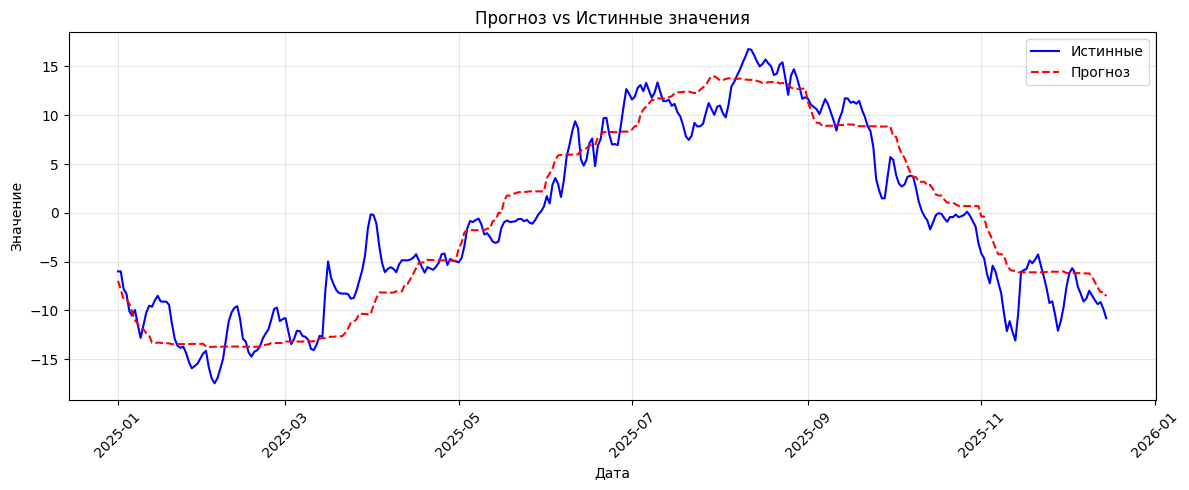

In [58]:
model = joblib.load(model_path)
last_window = df_train_full[target_col].iloc[-len(model.lags):]
y_pred = model.predict(
            steps=len(df_test),
            exog=df_test[exog_cols],
            last_window = last_window
        )

rmse = np.sqrt(mean_squared_error(df_test[target_col], y_pred))
print(f'RMSE на тесте = {rmse}')

plot_forecast(df_test[target_col], y_pred)

In [59]:
importances = model.get_feature_importances()
importances

,feature,importance
1,lag_2,0.315480
4,Месяц_cos,0.237177
0,lag_1,0.218057
2,lag_3,0.146934
6,day_of_year_cos,0.041804
5,day_of_year_sin,0.039366
3,Месяц_sin,0.001183
